# HATR cross-framework — Qualità di regressione

Confronto di `HoeffdingAdaptiveTreeRegressor` in River e CapyMOA su 4 dataset in prequential evaluation, con due configurazioni: deterministica (`mean`, no bootstrap) per misurare la consistenza, e default (`adaptive`, bootstrap) per la qualità realistica.

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jpype
import jpype.config
jpype.config.destroy_jvm = False

HATR_JAR = os.path.normpath(os.path.join(os.getcwd(), '..', 'implementation',
    'hatr-moa', 'target',
    'hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar'))
assert os.path.exists(HATR_JAR), f"JAR non trovato: {HATR_JAR}\ncompilare: cd implementation/hatr-moa && mvn -o package -DskipTests"

if jpype.isJVMStarted():
    print('JVM già avviata — Kernel -> Restart & Run All')
else:
    os.environ["CAPYMOA_JVM_ARGS"] = "-Xmx8g -Xss10M -XX:ErrorFile=/dev/null"
    jpype.addClassPath(HATR_JAR)

from capymoa.datasets import Bike, Fried
from capymoa.stream.generator import HyperPlaneRegression

import utils   # importato dopo JVM: gestisce sys.path, capymoa, river, hatr_capymoa

print("Setup OK — JVM avviata, HATR caricato, River e CapyMOA importati")

Setup OK — JVM avviata, HATR caricato, River e CapyMOA importati


## Dataset

In [2]:
MAX_INSTANCES = 17000
SYN_N, SYN_DRIFT = 17000, 5000

import urllib.request, gzip, shutil

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), 'data'))
os.makedirs(DATA_DIR, exist_ok=True)

_ELEC_PATH = os.path.join(DATA_DIR, 'electricity.arff')
_ELEC_URL  = 'https://www.dropbox.com/scl/fi/p7btran9xdas20neva917/electricity.arff.gz?rlkey=xt8hc6542b8wr01eitcw7mwpz&st=paqojdax&dl=1'
if not os.path.exists(_ELEC_PATH):
    print('Downloading electricity.arff...')
    _gz = _ELEC_PATH + '.gz'
    urllib.request.urlretrieve(_ELEC_URL, _gz)
    with gzip.open(_gz, 'rb') as _f_in, open(_ELEC_PATH, 'wb') as _f_out:
        shutil.copyfileobj(_f_in, _f_out)
    os.remove(_gz)
    print('Done.')

datasets = {}
datasets["Synthetic"]         = utils.make_synthetic(n=SYN_N, drift_at=SYN_DRIFT)
datasets["Bike"]              = utils.materialize_stream(Bike(), MAX_INSTANCES)
datasets["Fried"]             = utils.materialize_stream(Fried(), MAX_INSTANCES)
datasets["Hyper"]             = utils.materialize_stream(
    HyperPlaneRegression(instance_random_seed=1, number_of_attributes=10,
                         number_of_drifting_attributes=2, magnitude_of_change=0.001,
                         noise_percentage=5),
    MAX_INSTANCES)
datasets["HyperFast"]         = utils.materialize_stream(
    HyperPlaneRegression(instance_random_seed=1, number_of_attributes=10,
                         number_of_drifting_attributes=5, magnitude_of_change=0.1,
                         noise_percentage=10),
    MAX_INSTANCES)
datasets["FriedDrift"]        = utils.make_fried_drift(
    n=MAX_INSTANCES, drift_at=MAX_INSTANCES // 2)
datasets["RBFReg"]            = utils.make_rbf_regression(
    n=MAX_INSTANCES, drift_at=MAX_INSTANCES // 2)
datasets["ElectricityDemand"] = utils.load_electricity_demand(
    os.path.join(DATA_DIR, 'electricity.arff'), max_instances=MAX_INSTANCES)

for name, (X, y, schema) in datasets.items():
    print(f"{name:<20} n={len(X):>6}  feat={X.shape[1]:>2}  y\u2208[{y.min():.2f}, {y.max():.2f}]")

Synthetic            n= 17000  feat= 5  y∈[-14.29, 15.55]
Bike                 n= 17000  feat=12  y∈[1.00, 977.00]
Fried                n= 17000  feat=10  y∈[-1.23, 30.05]
Hyper                n= 17000  feat=10  y∈[93.98, 677.42]
HyperFast            n= 17000  feat=10  y∈[-4117.78, 11925.45]
FriedDrift           n= 17000  feat=10  y∈[-0.69, 30.15]
RBFReg               n= 17000  feat=10  y∈[-13.18, 16.44]
ElectricityDemand    n= 17000  feat= 7  y∈[0.00, 0.94]


## Parametri

In [3]:
BASE = dict(grace_period=200, delta=1e-7, tau=0.05, model_selector_decay=0.95,
            drift_window_threshold=300, switch_significance=0.05,
            min_samples_split=5, adwin_delta=0.002, seed=0)

CONFIGS = {
    "deterministic (mean, no-bootstrap)": dict(leaf_prediction="mean",     bootstrap_sampling=False),
    "default (adaptive, bootstrap)":      dict(leaf_prediction="adaptive", bootstrap_sampling=True),
}

SCALE = True
SKIP  = 50

## Esecuzione

In [4]:
rows = []
preds_cache = {}   # (dataset, config) -> (yt, river_pred, capy_pred)

CFG = CONFIGS["default (adaptive, bootstrap)"]
# warmup JVM: evita che il JIT di HotSpot penalizzi il primo dataset (Bike)
_w_X, _w_y, _w_schema = next(iter(datasets.values()))
utils.prequential_eval(_w_X[:10000], _w_y[:10000], 'capy', CFG, BASE, schema=_w_schema, scale=SCALE)

for ds_name, (X, y, schema) in datasets.items():
    for cfg_name, cfg in CONFIGS.items():
        rp, *_ = utils.prequential_eval(X, y, 'river', cfg, BASE, scale=SCALE)
        cp, *_ = utils.prequential_eval(X, y, 'capy', cfg, BASE, schema=schema, scale=SCALE)
        preds_cache[(ds_name, cfg_name)] = (y, rp, cp)
        rows.append(dict(dataset=ds_name, config=cfg_name, framework="River",
                         MAE=utils.mae(y[SKIP:], rp[SKIP:]),
                         RMSE=utils.rmse(y[SKIP:], rp[SKIP:]),
                         R2=utils.r2(y[SKIP:], rp[SKIP:])))
        rows.append(dict(dataset=ds_name, config=cfg_name, framework="CapyMOA",
                         MAE=utils.mae(y[SKIP:], cp[SKIP:]),
                         RMSE=utils.rmse(y[SKIP:], cp[SKIP:]),
                         R2=utils.r2(y[SKIP:], cp[SKIP:])))
        print(f"  {ds_name:<10} | {cfg_name:<32} | done")

results = pd.DataFrame(rows)
print("\nRisultati completi:")
results

  Synthetic  | deterministic (mean, no-bootstrap) | done
  Synthetic  | default (adaptive, bootstrap)    | done
  Bike       | deterministic (mean, no-bootstrap) | done
  Bike       | default (adaptive, bootstrap)    | done
  Fried      | deterministic (mean, no-bootstrap) | done
  Fried      | default (adaptive, bootstrap)    | done
  Hyper      | deterministic (mean, no-bootstrap) | done
  Hyper      | default (adaptive, bootstrap)    | done
  HyperFast  | deterministic (mean, no-bootstrap) | done
  HyperFast  | default (adaptive, bootstrap)    | done
  FriedDrift | deterministic (mean, no-bootstrap) | done
  FriedDrift | default (adaptive, bootstrap)    | done
  RBFReg     | deterministic (mean, no-bootstrap) | done
  RBFReg     | default (adaptive, bootstrap)    | done
  ElectricityDemand | deterministic (mean, no-bootstrap) | done
  ElectricityDemand | default (adaptive, bootstrap)    | done

Risultati completi:


,dataset,config,framework,MAE,RMSE,R2
0,Synthetic,"deterministic (mean, no-bootstrap)",River,0.936692,1.526978,0.786979
1,Synthetic,"deterministic (mean, no-bootstrap)",CapyMOA,0.936692,1.526978,0.786979
2,Synthetic,"default (adaptive, bootstrap)",River,0.295443,0.525618,0.974760
3,Synthetic,"default (adaptive, bootstrap)",CapyMOA,0.296821,0.526074,0.974716
4,Bike,"deterministic (mean, no-bootstrap)",River,83.794728,120.472345,0.562488
5,Bike,"deterministic (mean, no-bootstrap)",CapyMOA,83.794728,120.472345,0.562488
6,Bike,"default (adaptive, bootstrap)",River,68.006317,129.246514,0.496438
7,Bike,"default (adaptive, bootstrap)",CapyMOA,67.424238,113.793457,0.609654
8,Fried,"deterministic (mean, no-bootstrap)",River,2.493055,3.120910,0.608518
9,Fried,"deterministic (mean, no-bootstrap)",CapyMOA,2.493055,3.120910,0.608518


## Qualità

In [5]:
pivot = results.pivot_table(index=["dataset", "config"], columns="framework",
                            values=["MAE", "RMSE", "R2"])
pivot = pivot.reorder_levels([1, 0], axis=1).sort_index(axis=1)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
pivot

framework                                              CapyMOA         \
                                                           MAE     R2   
dataset           config                                                
Bike              default (adaptive, bootstrap)        67.4242 0.6097   
                  deterministic (mean, no-bootstrap)   83.7947 0.5625   
ElectricityDemand default (adaptive, bootstrap)         0.0549 0.6905   
                  deterministic (mean, no-bootstrap)    0.0711 0.6537   
Fried             default (adaptive, bootstrap)         1.8664 0.7688   
                  deterministic (mean, no-bootstrap)    2.4931 0.6085   
FriedDrift        default (adaptive, bootstrap)         2.1004 0.7011   
                  deterministic (mean, no-bootstrap)    2.7735 0.5094   
Hyper             default (adaptive, bootstrap)         9.4578 0.9412   
                  deterministic (mean, no-bootstrap)   46.7968 0.3030   
HyperFast         default (adaptive, bootstrap)       255.5083 0.9711   
                  deterministic (mean, no-bootstrap) 1163.2475 0.6381   
RBFReg            default (adaptive, bootstrap)         2.0426 0.2331   
                  deterministic (mean, no-bootstrap)    2.1697 0.1754   
Synthetic         default (adaptive, bootstrap)         0.2968 0.9747   
                  deterministic (mean, no-bootstrap)    0.9367 0.7870   

framework                                                          River  \
                                                          RMSE       MAE   
dataset           config                                                   
Bike              default (adaptive, bootstrap)       113.7935   68.0063   
                  deterministic (mean, no-bootstrap)  120.4723   83.7947   
ElectricityDemand default (adaptive, bootstrap)         0.0867    0.0520   
                  deterministic (mean, no-bootstrap)    0.0917    0.0711   
Fried             default (adaptive, bootstrap)         2.3982    1.7824   
                  deterministic (mean, no-bootstrap)    3.1209    2.4931   
FriedDrift        default (adaptive, bootstrap)         2.7121    1.9375   
                  deterministic (mean, no-bootstrap)    3.4747    2.7735   
Hyper             default (adaptive, bootstrap)        17.0015    8.7455   
                  deterministic (mean, no-bootstrap)   58.5224   46.7968   
HyperFast         default (adaptive, bootstrap)       417.4992  247.1162   
                  deterministic (mean, no-bootstrap) 1476.7088 1163.2475   
RBFReg            default (adaptive, bootstrap)         2.6623    2.1128   
                  deterministic (mean, no-bootstrap)    2.7605    2.1697   
Synthetic         default (adaptive, bootstrap)         0.5261    0.2954   
                  deterministic (mean, no-bootstrap)    1.5270    0.9367   

framework                                                              
                                                         R2      RMSE  
dataset           config                                               
Bike              default (adaptive, bootstrap)      0.4964  129.2465  
                  deterministic (mean, no-bootstrap) 0.5625  120.4723  
ElectricityDemand default (adaptive, bootstrap)      0.7489    0.0781  
                  deterministic (mean, no-bootstrap) 0.6537    0.0917  
Fried             default (adaptive, bootstrap)      0.7878    2.2976  
                  deterministic (mean, no-bootstrap) 0.6085    3.1209  
FriedDrift        default (adaptive, bootstrap)      0.7437    2.5118  
                  deterministic (mean, no-bootstrap) 0.5094    3.4747  
Hyper             default (adaptive, bootstrap)      0.9455   16.3702  
                  deterministic (mean, no-bootstrap) 0.3030   58.5224  
HyperFast         default (adaptive, bootstrap)      0.9738  397.5524  
                  deterministic (mean, no-bootstrap) 0.6381 1476.7088  
RBFReg            default (adaptive, bootstrap)      0.1918    2.7329  
               

## Grafici

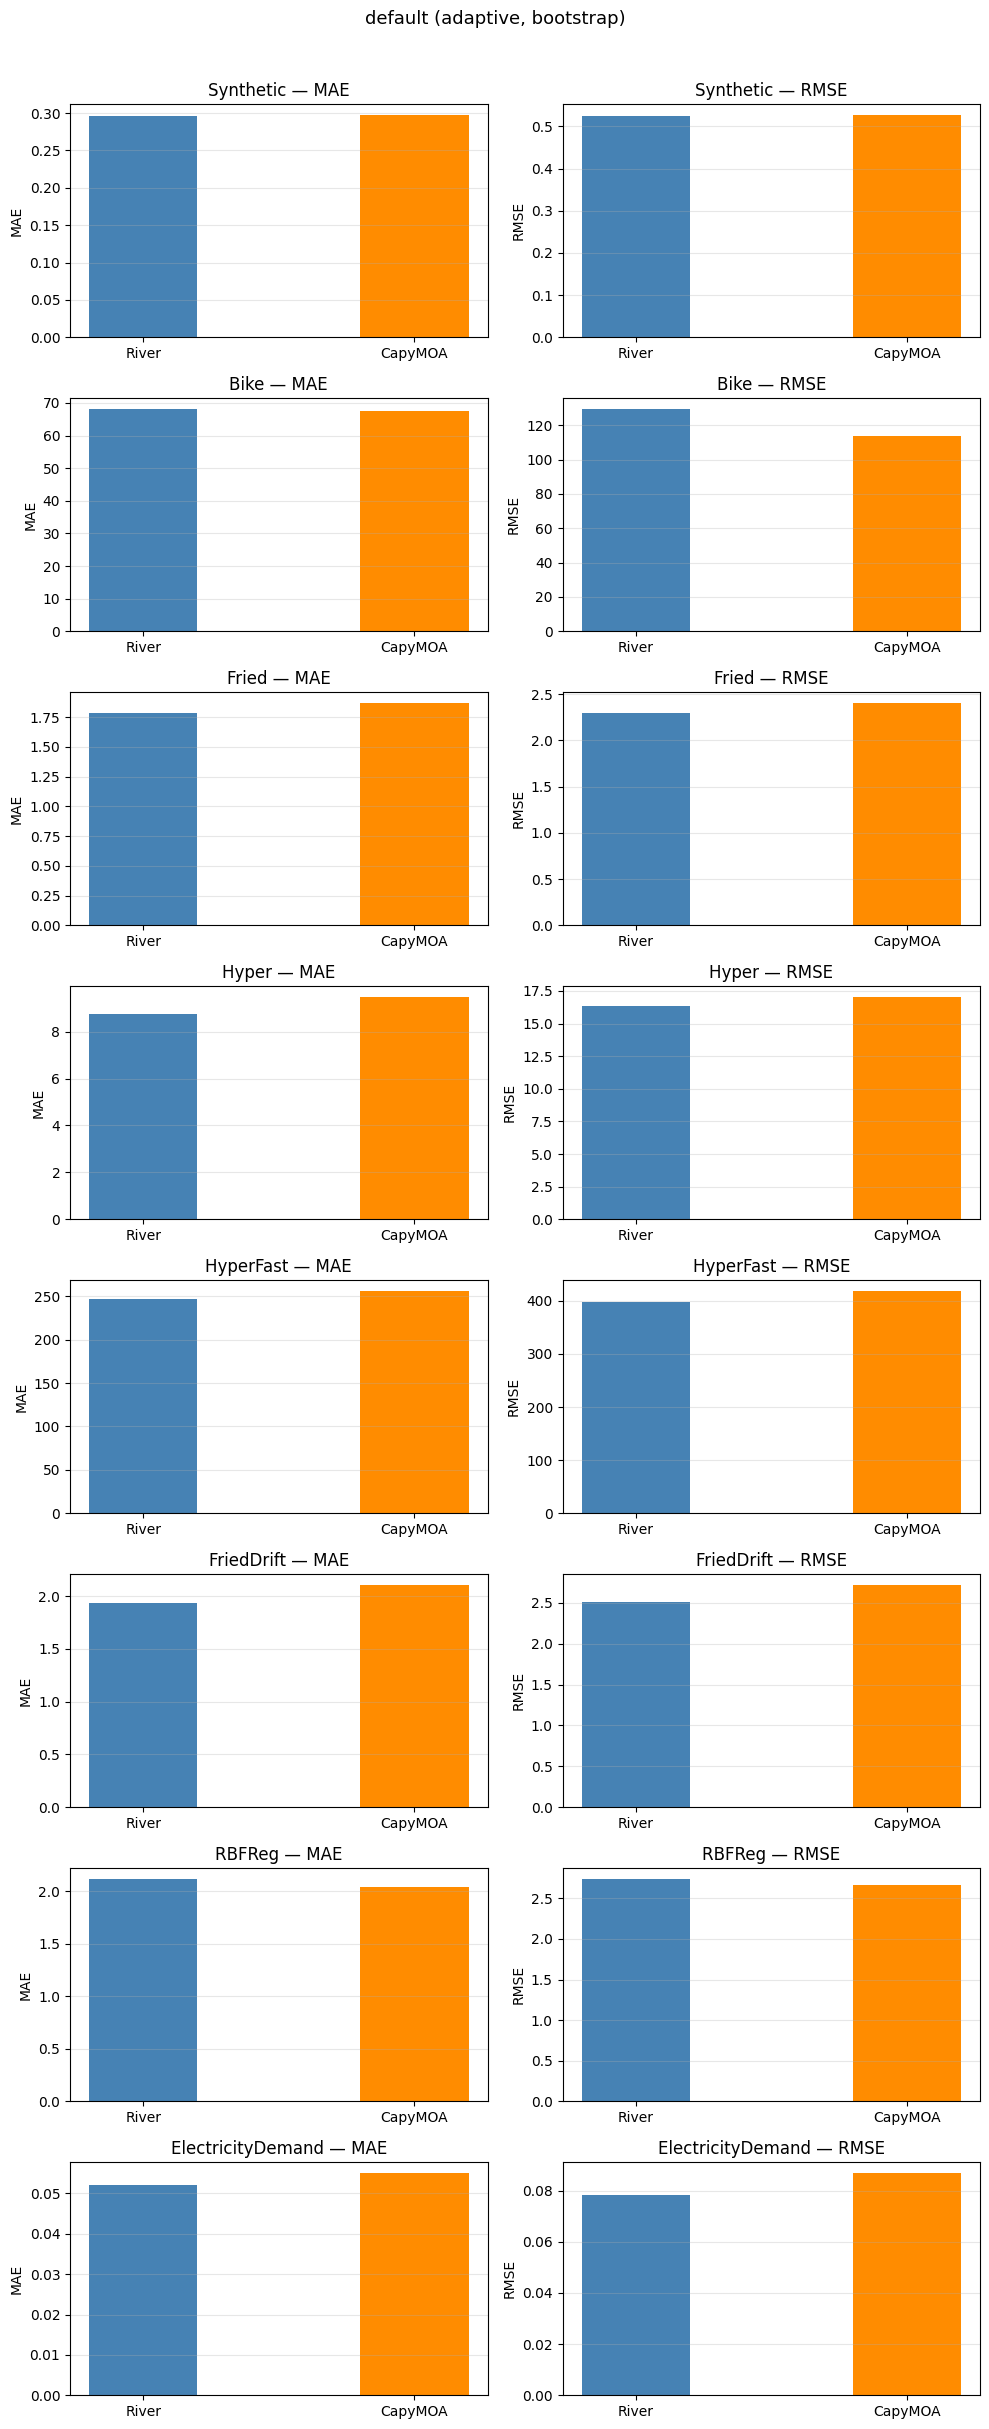

In [6]:
cfg_plot = "default (adaptive, bootstrap)"
sub      = results[results.config == cfg_plot]
ds_order = list(datasets.keys())
metrics  = ["MAE", "RMSE"]
colors   = {"River": "steelblue", "CapyMOA": "darkorange"}

fig, axes = plt.subplots(len(ds_order), 2,
                         figsize=(10, 3 * len(ds_order)),
                         squeeze=False)

for row, ds in enumerate(ds_order):
    ds_sub = sub[sub.dataset == ds]
    for col, metric in enumerate(metrics):
        ax  = axes[row, col]
        rv  = ds_sub[ds_sub.framework == "River"][metric].values[0]
        cm  = ds_sub[ds_sub.framework == "CapyMOA"][metric].values[0]
        ax.bar([0], [rv], 0.4, label="River",   color=colors["River"])
        ax.bar([1], [cm], 0.4, label="CapyMOA", color=colors["CapyMOA"])
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["River", "CapyMOA"])
        ax.set_ylabel(metric)
        ax.set_title(f"{ds} — {metric}")
        ax.grid(alpha=0.3, axis="y")

fig.suptitle(cfg_plot, fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Consistenza (deterministico)

In [9]:
cfg_det = "deterministic (mean, no-bootstrap)"
cons = []
for ds_name in datasets.keys():
    yt, rp, cp = preds_cache[(ds_name, cfg_det)]
    d = np.abs(rp - cp)
    corr = np.corrcoef(rp[SKIP:], cp[SKIP:])[0, 1]
    cons.append(dict(dataset=ds_name,
                     corr=corr,
                     MAE_river=utils.mae(yt[SKIP:], rp[SKIP:]),
                     MAE_capy=utils.mae(yt[SKIP:], cp[SKIP:]),
                     dMAE=abs(utils.mae(yt[SKIP:], rp[SKIP:]) - utils.mae(yt[SKIP:], cp[SKIP:]))))
cons_df = pd.DataFrame(cons)
print("Consistenza (mean, no bootstrap):")
cons_df

Consistenza (mean, no bootstrap):


,dataset,corr,MAE_river,MAE_capy,dMAE
0,Synthetic,1.0000,0.9367,0.9367,0.0000
1,Bike,1.0000,83.7947,83.7947,0.0000
2,Fried,1.0000,2.4931,2.4931,0.0000
3,Hyper,1.0000,46.7968,46.7968,0.0000
4,HyperFast,1.0000,1163.2475,1163.2475,0.0000
5,FriedDrift,1.0000,2.7735,2.7735,0.0000
6,RBFReg,1.0000,2.1697,2.1697,0.0000
7,ElectricityDemand,1.0000,0.0711,0.0711,0.0000


## Discussione

**Modalità deterministica (`mean`, no bootstrap).** Le implementazioni condividono lo stesso algoritmo; ci si aspettano predizioni identiche (corr ≈ 1, delta_MAE ≈ 0).

**Modalità default (`adaptive` + bootstrap).** Le RNG divergono (Python MT vs `java.util.Random`): le predizioni puntuali non coincidono, ma MAE/RMSE aggregati restano vicini. Per valutare la qualità reale è questo il confronto corretto.

**Standardizzazione.** `SCALE=True` applica lo stesso `StandardScaler` online a entrambi i lati; non introduce asimmetrie.